# Laplaciano em Grafos - Exercícios

## Luis Gustavo Nonato  <br>
ICMC-USP

----

## Exercício 1
Construa uma matriz de adjacência $20\times 20$ de forma randômica, assegurando que ela satisfaz as propriedades de uma matriz de adjecência de um grafo conexo, ou seja:

1. toda linha deve ter pelo menos uma entrada não nula
2. todas os elementos da diagonal devem ser zero
3. a matriz deve ser simétrica

In [8]:
import numpy as np

n=20

A = np.zeros((n,n))
for i in range(n):
    A[i,np.random.choice(np.arange(n),3,replace=False)] = 1 # forçando 3 entradas diferentes não
                                                            # nulas por linha (pode ser na diagonal)

A = A + A.T  # forçando simetria

A[np.arange(n),np.arange(n)] = 0 # forçando diagonal ser zero

ids = np.where(A != 0)  # fazendo com que as entradas não nulas sejam iguais a 1
A[ids] = 1

print('A matriz é simética:',np.all((A-A.T)<1.0e-7))
print(A)

A matriz é simética: True
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 1. 0. 0. 1.]
 [0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1.]
 [1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 1.]
 [1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 

## Exercício 2
Utilizando as bibliotecas <font color='blue'> networkx </font> e <font color='blue'> matplotlib </font> visualize o grafo correspondente à matriz de adjacência gerada no exercício 1.

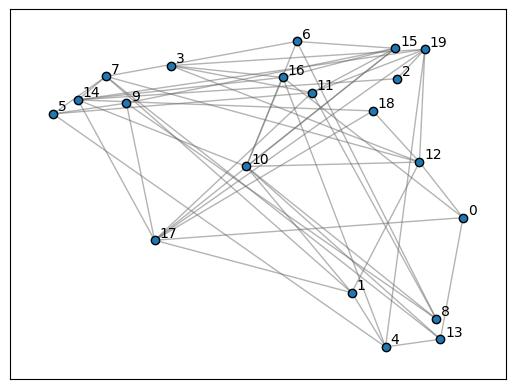

In [9]:
import networkx as ntx
import matplotlib.pyplot as plt
%matplotlib inline

X = np.random.uniform(0,1,size=(n,2)) # coordenadas dos vértices randômicas
G = ntx.from_numpy_array(A)
ntx.draw_networkx_edges(G, pos=X, edge_color='dimgray',alpha=0.5)
plt.scatter(X[:,0],X[:,1],edgecolor='k')

eps=1e-2
for i, txt in enumerate(range(n)):
    plt.annotate(txt, (X[i,0]+eps, X[i,1]+eps))

## Exercício 3
Construa a matriz Laplaciana associada a matriz de adjacência gerada no exercício 1. Utilize o espectro da Laplaciana para realizar "embedding" do grafo em duas dimensões.

In [10]:
from scipy import sparse

D = np.diag(np.sum(A,axis=1))
L = D - A

a, U = sparse.linalg.eigsh(L,k=3,M=D,which='SM')

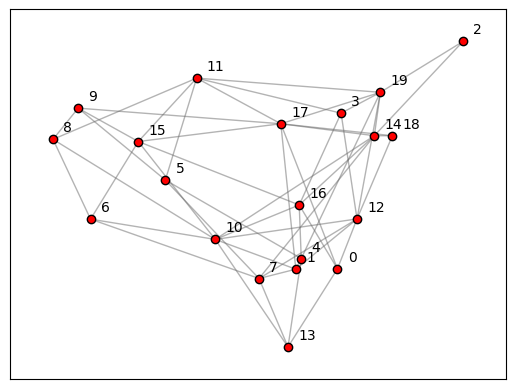

In [11]:
ntx.draw_networkx_edges(G, pos=U[:,1:], edge_color='dimgray',alpha=0.5)
plt.scatter(U[:,1],U[:,2],c='r',edgecolor='k')

eps=1e-2
for i, txt in enumerate(range(n)):
    plt.annotate(txt, (U[i,1]+eps, U[i,2]+eps))

## Exercício 4
Considere o conjunto de pontos gerado na célula abaixo e armazenados na variável `X`. Utilizando o pacote <font color='blue'> connected_knn </font> disponível para download no repositório do curso, construa o grafo de vizinhos mais próximos e visualize o grafo gerado.

A variável `labels_id` contém índices de três pontos localizados em diverentes locais do conjunto de pontos. Quando estiver visualizando o gráfico de vizinhos mais próximos, colorir os três pontos indicados em `labels_id` com cores distintas e todos os demais vértices com a mesma cor, a qual deve ser diferente das três anteriores.

In [12]:
from sklearn.datasets import make_blobs
import numpy as np
import scipy as scp
from scipy import sparse
import my_connected_knn as cknn
import networkx as ntx
import matplotlib.pyplot as plt
%matplotlib inline

n_samples = 200
centers = [(-2, 2), (0, -2), (2, 2)]
X,y  = make_blobs(n_samples=n_samples, centers=centers, shuffle=False, random_state=6)

labels_id = []
for i in np.unique(y):
    labels_id.append(np.where(y == i)[0][0])

print(labels_id)

[np.int64(0), np.int64(67), np.int64(134)]


In [13]:
A = cknn.connected_knn(X,extra_neighbors=3)
A = np.asarray(scp.sparse.csr_matrix.todense(A))
ids = np.where(A > 1e-8)
A[ids] = 1

labels = np.zeros(n_samples)
labels[labels_id] = [1,2,3]

In [14]:
np.savetxt('M_adj.txt',A)

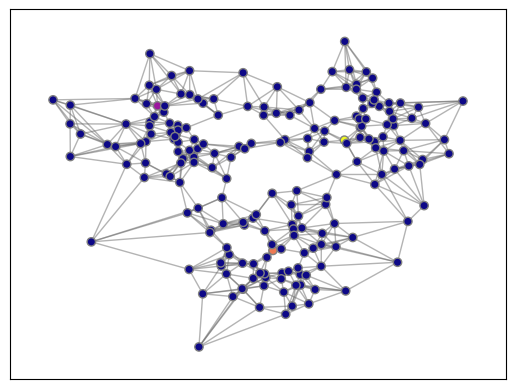

In [16]:
C = ntx.from_numpy_array(A)
ntx.draw_networkx_edges(C, pos=X, edge_color='dimgray',alpha=0.5)
plt.scatter(X[:,0],X[:,1],c=labels,edgecolor='gray',cmap='plasma')

## Exercício 5
Utilizaando o grafo gerado no exercício 4, propague o rótulo dos vértices indicados na variável `labels_id` a fim de identificar três grupos bem definidos de vértices. Compara visualmente o resultado obtido com a propagação dos rótulos com os rótulos definidos na variável `y` gerada no exercício 4.

In [17]:
L = np.diag(np.sum(A,axis=1).ravel()) - A
S, U = np.linalg.eigh(L)

labels = np.zeros((L.shape[0],len(labels_id)))
labels[labels_id,list(range(len(labels_id)))] = 1
k = 3
for i in range(len(labels_id)):
    vp = np.dot(U[:,1:k].T,labels[:,i])
    labels[:,i] = np.dot(U[:,1:k],vp[:k])

labels_prop = np.argmax(labels,axis=1)

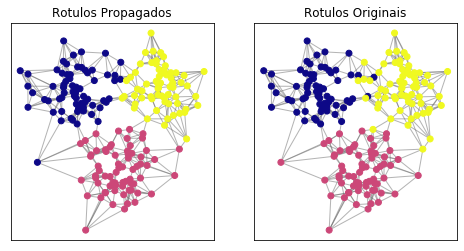

In [ ]:
f, (ax1,ax2) = plt.subplots(1,2,figsize=(8,4))
ax1.axes.set_xticks([])
ax1.axes.set_yticks([])
ax1.axes.set_title('Rotulos Propagados')
ntx.draw_networkx_edges(C, pos=X, edge_color='dimgray',alpha=0.5,ax=ax1)
ax1.scatter(X[:,0],X[:,1],c=labels_prop,cmap='plasma')

ax2.axes.set_xticks([])
ax2.axes.set_yticks([])
ax2.axes.set_title('Rotulos Originais')
ntx.draw_networkx_edges(C, pos=X, edge_color='dimgray',alpha=0.5,ax=ax2)
ax2.scatter(X[:,0],X[:,1],c=y,cmap='plasma')

## Exercício 6
Considere o grafo gerado no exercício 4. Enumere os vértices com números inteiros de modo que a suma

$$
\sum_{ij \in E} (nv_i - nv_j)^2
$$

seja a menor possível, onde $E$ é o conjunto de arestas do grafo e $nv_i$ é o número atribuido ao vértice $v_i$.

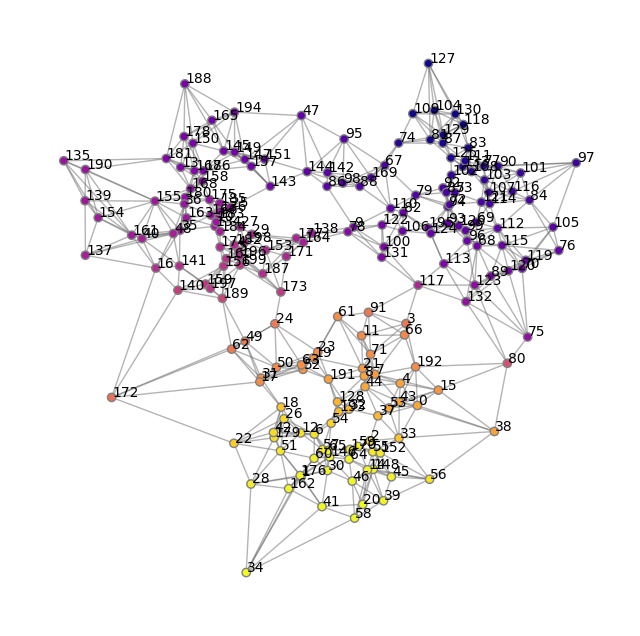

In [18]:
# a solução acima é dada pelo vetor de Fiedler. Se ordenarmos os vértices de acordo
# as entradas no vetor de Fiedler e enumerarmos os vértices de acordo com
# ordenação obtemos a numeração desejada

enumeracao_fiedler = np.argsort(U[:,1])

plt.figure(figsize=(8,8))
plt.axis('off')
ntx.draw_networkx_edges(C, pos=X, edge_color='dimgray',alpha=0.5)
plt.scatter(X[:,0],X[:,1],c=U[:,1],edgecolor='gray',cmap='plasma')

eps=1e-2
for i, txt in enumerate(enumeracao_fiedler):
    plt.annotate(txt, (X[i,0]+eps, X[i,1]+eps))

## Exercício 7
Pense em uma maneira de verificar, mesmo que numericamente, que a solução encontrada no exercício 6 está correta.

In [19]:
# Uma verificação grosseira, mas que dá um indicativo de que a ordenação baseada no vetor
# Fiedler minimiza a soma indicada no exercício 6, é gerar vetores com enumeração randômica
# e comparar com a enumeração dada pelo Fiedler

####### calculando as arestas do grafo #######
edges = list(C.edges())
print(edges[0:10])

####### Calculando a soma da enumeração dada pelo vetor de Fiedler ########
soma_fiedler = sum([(np.where(enumeracao_fiedler == i[0])[0][0] - np.where(enumeracao_fiedler == i[1])[0][0])**2 for i in edges])

####### Gerando enumeracoes randomicas ########
nk = 100     # numero de vetores randomicos
l_somas = [] # lista contendo todos os valores obtidos das somas
for k in range(nk):
    vk = np.arange(L.shape[0])
    np.random.shuffle(vk)
    soma = sum([(np.where(vk == i[0])[0][0] - np.where(vk == i[1])[0][0])**2 for i in edges])
    l_somas.append(soma)

print('Menor valor da lista de somas',max(l_somas))
print('Valor da soma no vetor de Fiedler',soma_fiedler)

[(0, 6), (0, 14), (0, 19), (0, 21), (0, 26), (0, 31), (0, 42), (0, 55), (1, 22), (1, 30)]
Menor valor da lista de somas 5751438
Valor da soma no vetor de Fiedler 70409


## Exercício 8
O método <font color='blue'> imshow() </font> do <font color='blue'> matplotlib </font> permite visualizar uma matriz como se fosse uma imagem. Por exemplo, o código abaixo gera uma matriz de adjacência e a visualiza como uma imagem.

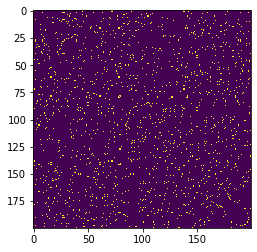

In [ ]:
import numpy as np
import scipy as scp
from scipy import sparse
import connected_knn as cknn
import networkx as ntx
import matplotlib.pyplot as plt
%matplotlib inline

n_samples = 200
X = np.random.uniform(-1,1,size=(200,2))

A = cknn.connected_knn(X,extra_neighbors=3)
A = np.asarray(scp.sparse.csr_matrix.todense(A))
ids = np.where(A > 1e-8)
A[ids] = 1

plt.imshow(A)

Utilize o esquema de enumração de vértices descrito no exercício 6 para reconstruir a matriz $A$ de modo que os vértices do grafo associado a matriz estejam indexados de acordo com a nova enumeração. Utilize o <font color='blue'> imshow() </font> e veja como a matriz esta estruturada.

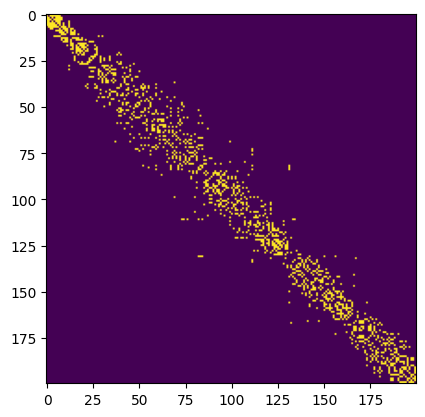

In [21]:
L = np.diag(np.sum(A,axis=1).ravel()) - A
S, U = np.linalg.eigh(L)

enumeracao_fiedler = np.argsort(U[:,1])

C = ntx.from_numpy_array(A)
edges = list(C.edges())

B = np.zeros(A.shape)
for i in edges:
    l = np.where(enumeracao_fiedler == i[0])[0][0]
    c = np.where(enumeracao_fiedler == i[1])[0][0]
    B[l,c] = 1
    B[c,l] = 1

plt.imshow(B)

# note que após a enumeração a matriz tende a ficar diagonal